## 剔除数据
### 1，分段
低段（约 < 75）：能量密度较低，致密度偏低，Jcorr较高，属于低能量工况区。

中段（约 75–100）：过渡区，致密度快速提升、Jcorr显著下降，数据点密度高，适合作为“稳态中段”。

高段（≥ 100）：高能量工况，致密度趋近高位、Jcorr趋低，样本较多但变化幅度相对收敛。

In [1]:
# Step 0: 导入库
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances_argmin
from sklearn.cluster import KMeans

# Step 1: 读取数据
df = pd.read_excel("data.xlsx")

# Step 2: 按能量密度分段
bins = [-np.inf, 81, 111, np.inf]
labels = ["Low", "Mid", "High"]
df["ED_bin"] = pd.cut(df["能量密度"], bins=bins, labels=labels)
# 统计每段样本数
# counts = df["ED_bin"].value_counts()：High 57，Mid 47，Low 40
feature_cols = ["功率","扫描速度","扫描间隙","层厚"]

# 剔除比例策略
ratios = {"Low": 0.12, "Mid": 0.18, "High": 0.22}

def stratified_remove(segment, remove_ratio=0.2, k_clusters=10,min_keep=30):
    if remove_ratio <= 0 or len(segment) < 20:
        return pd.DataFrame(columns=segment.columns), segment
   #动态簇数
    k = min(k_clusters, max(2, len(segment)//5))
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(segment[feature_cols].values)
    segment = segment.copy() # 保证不会修改df
    segment["cluster"] = km.labels_# 在segment中添加一列cluster，记录样本所属的簇

    # 保护簇中心点
    rep_idx = pairwise_distances_argmin(km.cluster_centers_, segment[feature_cols].values)# 获取簇中心点（或离中心点最近点）对应的索引
    segment["protect"] = False
    cluster_sizes = segment["cluster"].value_counts().to_dict()# 获取每个簇的样本数
    for idx in rep_idx:
       c = segment.loc[segment.index[idx], "cluster"]
       if cluster_sizes[c] >= 4:   # 只保护大簇
        segment.loc[segment.index[idx], "protect"] = True

    # 剔除配额
    remove_quota = int(len(segment) * remove_ratio)
    # 保证至少保留 min_keep
    remove_quota = min(remove_quota, max(0, len(segment) - min_keep))


    size_sum = sum(cluster_sizes.values())# 所有簇的样本数之和
     # 初步分配，用 round 避免全是 0
    removal_plan = {c: round(remove_quota * (cluster_sizes[c]/size_sum)) for c in cluster_sizes}# 计算每个簇需要删除的样本数

    # 保证大簇至少剔除 1 个（非保护点足够时）
    for c in removal_plan:
        if cluster_sizes[c] > 5 and removal_plan[c] == 0:
            removal_plan[c] = 1

    # 校正总数，避免超过 remove_quota
    total_assigned = sum(removal_plan.values())
    if total_assigned > remove_quota:
        # 按簇大小比例减少
        for c in sorted(removal_plan, key=lambda x: cluster_sizes[x], reverse=True):
            if total_assigned <= remove_quota:
                break
            if removal_plan[c] > 1:
                removal_plan[c] -= 1
                total_assigned -= 1

    removable = segment[~segment["protect"]].copy()# 获取可删除的样本
    to_remove_idx = []
    for c, num in removal_plan.items():
        cand = removable[removable["cluster"] == c]# 获取当前簇的样本
        if num > 0 and len(cand) > 0:#只有满足删除条件才执行
            pick = cand.sample(n=min(num, len(cand)), random_state=42).index.tolist()# 从当前簇中随机选择num个样本
            to_remove_idx.extend(pick)

    seg_removed = segment.loc[to_remove_idx].drop(columns=["cluster","protect"])
    seg_kept = segment.drop(index=to_remove_idx).drop(columns=["cluster","protect"])
    #print("=== Segment diagnostics ===")
    #print("样本总数:", len(segment))
    #print("目标剔除比例:", remove_ratio)
    #print("理论剔除配额:", int(len(segment) * remove_ratio))
    #print("实际剔除配额(考虑min_keep):", remove_quota)
    #print("簇数 k:", k)
    #print("保护点数量:", segment["protect"].sum())
    #print("非保护候选数量:", (~segment["protect"]).sum())
    #print("簇大小分布:", cluster_sizes)
    #print("初步分配计划:", removal_plan)

    #cand_counts = removable["cluster"].value_counts().to_dict()
    #print("各簇可删数:", cand_counts)
    #for c, num in removal_plan.items():
     #   print(f"簇 {c}: 计划剔除 {num}, 可删 {cand_counts.get(c,0)}")
    # 保证至少剔除 min_remove_floor 个（如果候选足够）
    min_remove_floor = 2 if remove_ratio < 0.15 else 0
    if len(removable) >= min_remove_floor and len(to_remove_idx) < min_remove_floor:
        extra = removable.drop(index=to_remove_idx).sample(
            n=min_remove_floor - len(to_remove_idx), random_state=42
        ).index.tolist()
        to_remove_idx.extend(extra)
    return seg_removed, seg_kept

removed_frames, kept_frames = [], []
for lab in labels:
    seg = df[df["ED_bin"] == lab].copy()
    seg_removed, seg_kept = stratified_remove(seg, remove_ratio=ratios[lab], k_clusters=10, min_keep=30)
    removed_frames.append(seg_removed.assign(ED_bin=lab))
    kept_frames.append(seg_kept.assign(ED_bin=lab))

removed_df = pd.concat(removed_frames, ignore_index=True)
kept_df = pd.concat(kept_frames, ignore_index=True)

#print("Kept counts:", kept_df["ED_bin"].value_counts().to_dict())
#print("Removed counts:", removed_df["ED_bin"].value_counts().to_dict())

removed_df.to_excel("removed_by_ED_bin.xlsx", index=False)
kept_df.to_excel("kept_by_ED_bin.xlsx", index=False)


## 模型训练

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from scipy.stats import randint, loguniform
#数据准备
X = kept_df[feature_cols]
y = kept_df[['致密度', '阻抗(MΩ cm-2)', 'Jcorr\n(μA cm-2)']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 定义搜索空间

In [3]:
search_spaces = {
    "RandomForest": {
        "model__estimator__n_estimators": randint(50, 200),
        "model__estimator__max_depth": randint(3, 20),
        "model__estimator__min_samples_split": randint(2, 10)
    },
    "XGBoost": {
        "model__estimator__n_estimators": randint(50, 200),
        "model__estimator__max_depth": randint(3, 10),
        "model__estimator__learning_rate": loguniform(1e-3, 0.3)
    },
    "LightGBM": {
        "model__estimator__n_estimators": randint(50, 200),
        "model__estimator__max_depth": randint(3, 10),
        "model__estimator__learning_rate": loguniform(1e-3, 0.3)
    },
    "SVR": {
        "model__estimator__C": loguniform(1e-2, 1e2),
        "model__estimator__gamma": loguniform(1e-3, 1e0),
        "model__estimator__kernel": ["rbf", "poly"]
    },
    "NeuralNet": {
        "model__estimator__hidden_layer_sizes": [(50,), (100,), (100,50)],
        "model__estimator__alpha": loguniform(1e-5, 1e-2),
        "model__estimator__learning_rate_init": loguniform(1e-4, 1e-2)
    },
    "LinearRegression": {
        "model__estimator__fit_intercept": [True, False]
    }
}

## 定义管道并进行随机搜索调参

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ==== 4. 定义基模型 ====
base_models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "SVR": SVR(),
    "NeuralNet": MLPRegressor(max_iter=1000, random_state=42),
    "LinearRegression": LinearRegression()
}
# ==== 5. 构建管道 ====
pipelines = {}

for name, model in base_models.items():
    if name in ["SVR", "NeuralNet", "LinearRegression", "Ridge", "Lasso"]:
        # 需要归一化的模型
        pipelines[name] = Pipeline([
            ("scaler", StandardScaler()),#标准化（归一化），把每个特征转换为 均值为 0、方差为 1 的分布
            ("model", MultiOutputRegressor(model))
        ])
    else:
        # 树模型，不需要归一化
        pipelines[name] = Pipeline([
            ("model", MultiOutputRegressor(model))
        ])

# ==== 6. 定义评分函数 ====
scoring = {
    "R2": make_scorer(r2_score, multioutput="uniform_average"),
    "MAE": make_scorer(mean_absolute_error, multioutput="uniform_average", greater_is_better=False),
    "RMSE": make_scorer(
        lambda y_true, y_pred: np.sqrt(
            mean_squared_error(y_true, y_pred, multioutput="uniform_average")
        ),
        greater_is_better=False
    )
}

# ==== 7. 训练与搜索 ====
results = {}
predictions = {}
best_pipes = {}

for name, pipe in pipelines.items():
    print(f"正在训练 {name} ...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=search_spaces[name],
        n_iter=20,              # 随机搜索迭代次数
        cv=3,                   # 交叉验证折数
        scoring=scoring,
        refit="R2",             # 用 R2 作为最终模型选择指标
        random_state=42,
        n_jobs=-1
    )

    # 超参数搜索
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)
    # ---- 整体平均指标 ----
    rmse_avg = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="uniform_average"))
    mae_avg = mean_absolute_error(y_test, y_pred, multioutput="uniform_average")
    r2_avg = r2_score(y_test, y_pred, multioutput="uniform_average")

    # ---- 每个输出单独指标 ----
    rmse_each = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    mae_each = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    r2_each = r2_score(y_test, y_pred, multioutput="raw_values")

    results[name] = {
        "Best Params": search.best_params_,
        "RMSE_avg": rmse_avg, "MAE_avg": mae_avg,
        "R2_avg": r2_avg,
        "RMSE_each": dict(zip(y.columns, rmse_each)),
        "MAE_each": dict(zip(y.columns, mae_each)),
        "R2_each": dict(zip(y.columns, r2_each))
    }
    # 保存结果
    rows = []
    for model, metrics in results.items():
        row = {
            "Model": model,
            "Best Params": str(metrics["Best Params"]),
            "RMSE_avg": metrics["RMSE_avg"],
            "MAE_avg": metrics["MAE_avg"],
            "R2_avg": metrics["R2_avg"],
        }
        # 把逐列指标也加进去
        for col in metrics["R2_each"].keys():
            row[f"RMSE_{col}"] = metrics["RMSE_each"][col]
            row[f"MAE_{col}"] = metrics["MAE_each"][col]
            row[f"R2_{col}"] = metrics["R2_each"][col]
        rows.append(row)

    predictions[name] = pd.DataFrame(y_pred, columns=y.columns, index=y_test.index)
    best_pipes[name] = search.best_estimator_

正在训练 RandomForest ...
正在训练 XGBoost ...
正在训练 LightGBM ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 96, number of used features: 4
[LightGBM] [Info] Start training from score 88.864584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=20. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## 模型性能评估

In [5]:
# ==== 8. 查看结果 ====
for name, res in results.items():
    print(f"\n{name} 最优参数: {res['Best Params']}")
    print(f"整体平均指标 -> R2_avg: {res['R2_avg']:.3f}, RMSE_avg: {res['RMSE_avg']:.3f}, MAE_avg: {res['MAE_avg']:.3f}")

    # 打印每个目标的单独指标
    print("逐目标指标：")
    for col in res["R2_each"].keys():
        r2_val = res["R2_each"][col]
        rmse_val = res["RMSE_each"][col]
        mae_val = res["MAE_each"][col]
        print(f"  {col}: R2={r2_val:.3f}, RMSE={rmse_val:.3f}, MAE={mae_val:.3f}")


# 转成 DataFrame
results_df = pd.DataFrame(rows)
results_df.to_excel("new_model_results.xlsx", index=True)


RandomForest 最优参数: {'model__estimator__max_depth': 14, 'model__estimator__min_samples_split': 2, 'model__estimator__n_estimators': 98}
整体平均指标 -> R2_avg: 0.860, RMSE_avg: 2.121, MAE_avg: 0.948
逐目标指标：
  致密度: R2=0.910, RMSE=3.673, MAE=2.794
  阻抗(MΩ cm-2): R2=0.730, RMSE=0.040, MAE=0.031
  Jcorr
(μA cm-2): R2=0.938, RMSE=0.026, MAE=0.019

XGBoost 最优参数: {'model__estimator__learning_rate': np.float64(0.10057690178153984), 'model__estimator__max_depth': 3, 'model__estimator__n_estimators': 139}
整体平均指标 -> R2_avg: 0.829, RMSE_avg: 2.459, MAE_avg: 1.105
逐目标指标：
  致密度: R2=0.880, RMSE=4.259, MAE=3.257
  阻抗(MΩ cm-2): R2=0.676, RMSE=0.044, MAE=0.034
  Jcorr
(μA cm-2): R2=0.930, RMSE=0.028, MAE=0.023

LightGBM 最优参数: {'model__estimator__learning_rate': np.float64(0.10057690178153984), 'model__estimator__max_depth': 3, 'model__estimator__n_estimators': 139}
整体平均指标 -> R2_avg: 0.793, RMSE_avg: 2.567, MAE_avg: 1.082
逐目标指标：
  致密度: R2=0.869, RMSE=4.446, MAE=3.176
  阻抗(MΩ cm-2): R2=0.656, RMSE=0.045, MAE=0.0

## 模型性能可视化

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="SimHei")
# 目标变量名称
targets = ['Density', 'Impedance (MΩ cm-2)', 'Jcorr\n(μA cm-2)']

# 建立中文列名 -> 英文显示名的映射
target_map = {
    '致密度': 'Density',
    '阻抗(MΩ cm-2)': 'Impedance (MΩ cm-2)',
    'Jcorr\n(μA cm-2)': 'Jcorr (μA cm-2)'   # 注意 key 必须和 y.columns 完全一致
}
# 新建保存文件夹
save_dir = "active_learning/old/plots"
os.makedirs(save_dir, exist_ok=True)

# 1. 真实值 vs 预测值散点图
for col, label in target_map.items():   # col=中文列名, label=英文显示名
    for name, y_pred_test in predictions.items():
        # 获取 train 预测
        y_pred_train = None
        if name in best_pipes:
            try:
                y_pred_train = best_pipes[name].predict(X_train)
            except Exception:
                pass

        measured_train = y_train[col].values if 'y_train' in globals() else None
        measured_test = y_test[col].values

        plt.figure(figsize=(5, 5), dpi=300)

        # 绘制 Train
        if y_pred_train is not None and measured_train is not None:
            idx = list(y.columns).index(col)   # 找到该列在 y 中的索引
            sns.scatterplot(
                x=measured_train,
                y=y_pred_train[:, idx],
                color='green',
                label='Train',
                alpha=0.6,
                s=30
            )

        # 绘制 Test（DataFrame 按中文列名取值）
        sns.scatterplot(
            x=measured_test,
            y=y_pred_test[col].values,
            color='magenta',
            label='Test',
            alpha=0.9,
            s=40
        )

        # 对角线
        all_vals = [measured_test, y_pred_test[col].values]
        if measured_train is not None:
            all_vals.append(measured_train)
        if y_pred_train is not None:
            all_vals.append(y_pred_train[:, idx])
        all_arr = np.concatenate(all_vals)
        lims = [all_arr.min(), all_arr.max()]
        plt.plot(lims, lims, 'k--', label='Diagonal line')

        # 坐标轴和标题（英文）
        plt.xlabel("Measured")
        plt.ylabel("Predicted")
        plt.title(f"{name} - {label}")

        # ---- 计算 Train/Test 指标 ----
        r2_train, rmse_train = None, None
        if y_pred_train is not None and measured_train is not None:
            r2_train = r2_score(measured_train, y_pred_train[:, idx])
            rmse_train = np.sqrt(mean_squared_error(measured_train, y_pred_train[:, idx]))

        r2_test = results[name]["R2_each"][col]
        rmse_test = results[name]["RMSE_each"][col]

        # ---- 在图上显示 ----
        ypos = 0.95
        if r2_train is not None:
            plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}", transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
            plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}", transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}", transform=plt.gca().transAxes, va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}", transform=plt.gca().transAxes, va='top', color="magenta")

        plt.legend()

        # 保存图像与数据
        model_dir = os.path.join(save_dir, "scatter", name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{name}_{label}".replace("/", "-")
        png_path = os.path.join(model_dir, base_fn + "_scatter.png")
        excel_path = os.path.join(model_dir, base_fn + "_scatter.xlsx")
        plt.savefig(png_path, bbox_inches="tight")
        plt.close()

        frames = []
        idx = list(y.columns).index(col)   # col 是中文列名

        # Train 部分
        if y_pred_train is not None and measured_train is not None:
            frames.append(pd.DataFrame({
                "Measured": measured_train,
                "Predicted": y_pred_train[:, idx],
                "Split": "Train",
                "Target": label   # 用英文名字标记目标
            }))

        # Test 部分
            frames.append(pd.DataFrame({
                "Measured": measured_test,
                "Predicted": y_pred_test[col].values,
                "Split": "Test",
                "Target": label
            }))

        #    合并并保存
            df_scatter = pd.concat(frames, ignore_index=True)
            df_scatter.to_excel(excel_path, index=False)
# 残差
for col, label in target_map.items():   # col=中文列名, label=英文显示名
    for name, y_pred_test in predictions.items():
        # 获取 train 预测
        y_pred_train = None
        if name in best_pipes:
            try:
                y_pred_train = best_pipes[name].predict(X_train)
            except Exception:
                pass

        measured_train = y_train[col].values if 'y_train' in globals() else None
        measured_test = y_test[col].values

        plt.figure(figsize=(5, 5), dpi=300)

        # 训练集残差点
        if y_pred_train is not None and measured_train is not None:
            idx = list(y.columns).index(col)
            residuals_train = measured_train - y_pred_train[:, idx]
            sns.scatterplot(
                x=y_pred_train[:, idx],
                y=residuals_train,
                color='green',
                label='Train',
                alpha=0.6,
                s=30
            )

        # 测试集残差点
        residuals_test = measured_test - y_pred_test[col].values
        sns.scatterplot(
            x=y_pred_test[col].values,
            y=residuals_test,
            color='magenta',
            label='Test',
            alpha=0.9,
            s=40
        )

        plt.axhline(0, color='red', linestyle='--')  # 理想残差线 y=0

        plt.xlabel("Predicted")
        plt.ylabel("Residual")
        plt.title(f"{name} - {label} Residuals")

        # ---- 计算 Train/Test 指标 ----
        r2_train, rmse_train = None, None
        if y_pred_train is not None and measured_train is not None:
            r2_train = r2_score(measured_train, y_pred_train[:, idx])
            rmse_train = np.sqrt(mean_squared_error(measured_train, y_pred_train[:, idx]))

        r2_test = results[name]["R2_each"][col]
        rmse_test = results[name]["RMSE_each"][col]

        # ---- 在图上显示 ----
        ypos = 0.95
        if r2_train is not None:
            plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}", transform=plt.gca().transAxes,
                           va='top', color="green"); ypos -= 0.05
            plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}", transform=plt.gca().transAxes,
                           va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}", transform=plt.gca().transAxes,
                       va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}", transform=plt.gca().transAxes,
                       va='top', color="magenta")

        plt.legend()

        # ---- 保存图像与数据 ----
        model_dir = os.path.join(save_dir, "residual", name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{name}_{label}".replace("/", "-")
        plt.savefig(os.path.join(model_dir, base_fn + "_residual_scatter.png"), bbox_inches="tight")
        plt.close()

        # ---- 保存残差数据到 Excel ----
        frames = []
        if y_pred_train is not None and measured_train is not None:
            frames.append(pd.DataFrame({
                "Predicted": y_pred_train[:, idx],
                "Residual": measured_train - y_pred_train[:, idx],
                "Split": "Train",
                "Target": label
            }))
        frames.append(pd.DataFrame({
            "Predicted": y_pred_test[col].values,
            "Residual": residuals_test,
            "Split": "Test",
            "Target": label
        }))
        df_residual = pd.concat(frames, ignore_index=True)
        df_residual.to_excel(os.path.join(model_dir, base_fn + "_residual_scatter.xlsx"), index=False)


# ---------- 误差分布直方图 / KDE（同时叠加 Train / Test 的分布） ----------
for col, label in target_map.items():   # col=中文列名, label=英文显示名
    for name, y_pred_test in predictions.items():
        # 获取 train 预测
        y_pred_train = None
        if name in best_pipes:
            try:
                y_pred_train = best_pipes[name].predict(X_train)
            except Exception:
                pass

        measured_train = y_train[col].values if 'y_train' in globals() else None
        measured_test = y_test[col].values

        # ---------- 误差分布直方图 / KDE ----------
        plt.figure(figsize=(5, 5), dpi=300)

        # 训练集残差
        if y_pred_train is not None and measured_train is not None:
            idx = list(y.columns).index(col)
            residuals_train = measured_train - y_pred_train[:, idx]
            sns.histplot(
                residuals_train,
                bins=30,
                color='green',
                label='Train',
                stat='count',
                kde=True,
                alpha=0.4
            )

        # 测试集残差
        residuals_test = measured_test - y_pred_test[col].values
        sns.histplot(
            residuals_test,
            bins=30,
            color='magenta',
            label='Test',
            stat='count',
            kde=True,
            alpha=0.4
        )

        plt.xlabel("Residual")
        plt.ylabel("Count")
        plt.title(f"{name} - {label} Residual Distribution")

        # ---- 计算 Train/Test 指标 ----
        r2_train, rmse_train = None, None
        if y_pred_train is not None and measured_train is not None:
            r2_train = r2_score(measured_train, y_pred_train[:, idx])
            rmse_train = np.sqrt(mean_squared_error(measured_train, y_pred_train[:, idx]))

        r2_test = results[name]["R2_each"][col]
        rmse_test = results[name]["RMSE_each"][col]

        # ---- 在图上显示 ----
        ypos = 0.95
        if r2_train is not None:
            plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}",
                           transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
            plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}",
                           transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}",
                       transform=plt.gca().transAxes, va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}",
                       transform=plt.gca().transAxes, va='top', color="magenta")

        plt.legend()

        # ---- 保存图像与数据 ----
        model_dir = os.path.join(save_dir, "hist", name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{name}_{label}".replace("/", "-")
        plt.savefig(os.path.join(model_dir, base_fn + "_residual_hist.png"), bbox_inches="tight")
        plt.close()

        # ---- 保存残差数据到 Excel ----
        df_hist_frames = []
        if y_pred_train is not None and measured_train is not None:
            df_hist_frames.append(pd.DataFrame({
                "Residual": measured_train - y_pred_train[:, idx],
                "Split": "Train",
                "Target": label
            }))
        df_hist_frames.append(pd.DataFrame({
            "Residual": residuals_test,
            "Split": "Test",
            "Target": label
        }))
        df_hist = pd.concat(df_hist_frames, ignore_index=True)
        df_hist.to_excel(os.path.join(model_dir, base_fn + "_residual_hist.xlsx"), index=False)

## PI

In [7]:
# ===== Cell: Permutation Importance =====
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import pandas as pd

plt.rc("font", family="SimHei")

X_cols = ['功率', '扫描速度', '扫描间隙', '层厚']
y_cols = ['致密度', '阻抗(MΩ cm-2)', 'Jcorr\n(μA cm-2)']

# 保存目录
save_root = "active_learning/old/plots"
pi_root = os.path.join(save_root, "pi")
os.makedirs(pi_root, exist_ok=True)

# 对每个模型、每个目标计算 PI
for name, est in best_pipes.items():
    model_dir = os.path.join(pi_root, name)
    os.makedirs(model_dir, exist_ok=True)

    # MultiOutputRegressor 内部的子模型
    mor = est.named_steps["model"]

    # Excel 文件路径（每个模型一个 Excel）
    excel_path = os.path.join(model_dir, f"{name}_PI.xlsx")

    # 每个模型一个 Excel 文件，里面多个 sheet
    with pd.ExcelWriter(excel_path, engine="openpyxl", mode="w") as writer:
        for idx, target in enumerate(y_cols):
            base_est = mor.estimators_[idx]

            # 判断是否有 scaler
            if "scaler" in est.named_steps:
                X_test_trans = est.named_steps["scaler"].transform(X_test)
            else:
                X_test_trans = X_test.values

            # 根据模型类型选择输入格式
            if isinstance(base_est, (RandomForestRegressor)):
                X_input = X_test_trans
            elif "LGBMRegressor" in str(type(base_est)) or "XGBRegressor" in str(type(base_est)):
                X_input = pd.DataFrame(X_test_trans, columns=X_test.columns, index=X_test.index)
            else:
                X_input = pd.DataFrame(X_test_trans, columns=X_test.columns, index=X_test.index)

            # 计算 PI
            result = permutation_importance(
                base_est,
                X_input,
                y_test.iloc[:, idx],
                scoring="neg_root_mean_squared_error",
                n_repeats=20,
                random_state=42,
                n_jobs=-1
            )

            importances = result.importances_mean
            order = np.argsort(importances)[::-1]

            # 绘制并保存图像
            plt.figure(figsize=(6, 4))
            sns.barplot(x=np.array(X_cols)[order], y=importances[order], color="#4C72B0")
            plt.ylabel("Permutation Importance（平均下降量，负RMSE）")
            plt.xlabel("特征")
            plt.title(f"{name} - {target} 的 PI")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            fname = f"{target}_PI.png".replace("\n", "")
            plt.savefig(os.path.join(model_dir, fname), dpi=300, bbox_inches="tight")
            plt.close()

            # 保存数值到 Excel
            df_importance = pd.DataFrame({
                "Feature": np.array(X_cols)[order],
                "Importance": importances[order]
            })
            sheet_name = target.replace("\n", "_")
            df_importance.to_excel(writer, sheet_name=sheet_name, index=False)


D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.war

## 模型性能相关性热力图

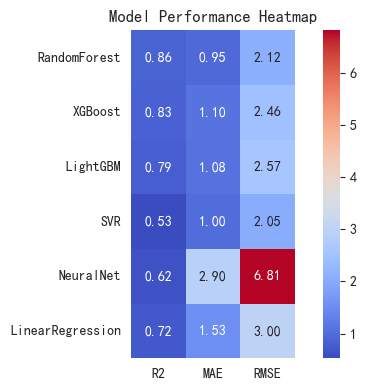

In [8]:
# ===== Cell: Model Performance Heatmap =====
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc("font", family="SimHei")  # 中文字体

perf_df = pd.DataFrame({
    model: {
        "R2": vals["R2_avg"],
        "MAE": vals["MAE_avg"],
        "RMSE": vals["RMSE_avg"]
    }
    for model, vals in results.items()
}).T



# 2) 绘制热力图
plt.figure(figsize=(6, 4))
sns.heatmap(perf_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Model Performance Heatmap")
plt.tight_layout()

# 3) 保存
save_root = "active_learning/old/plots"
perf_dir = os.path.join(save_root, "perf")
os.makedirs(perf_dir, exist_ok=True)

plt.savefig(os.path.join(perf_dir, "model_performance_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Pearson/Spearman correlation heatmaps
Pearson：线性关系、对异常值敏感。

Spearman：单调关系、对异常值更稳。

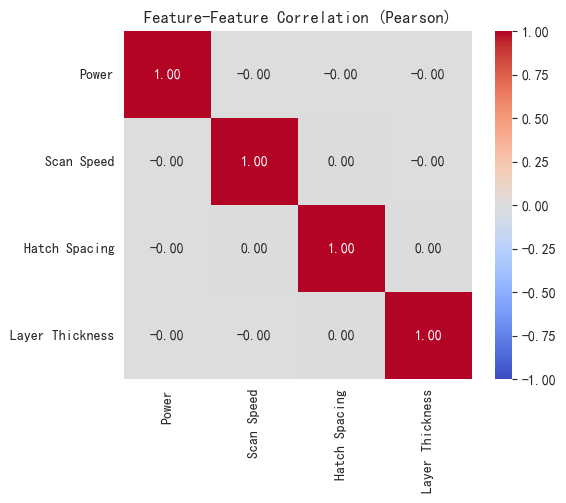

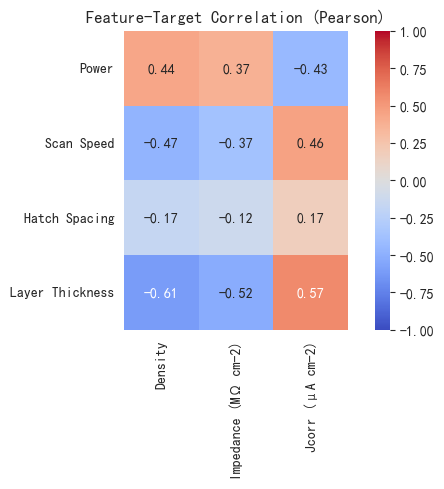

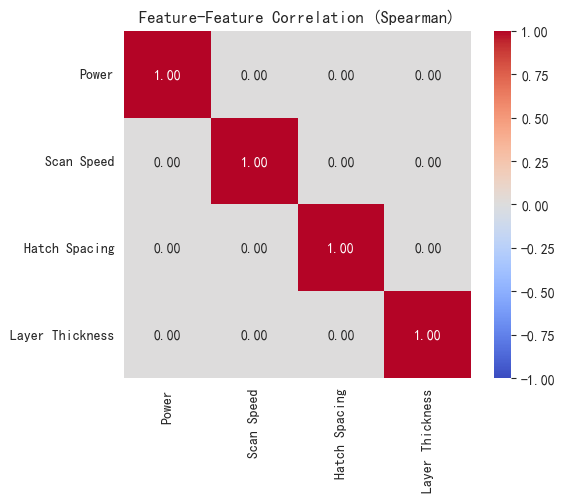

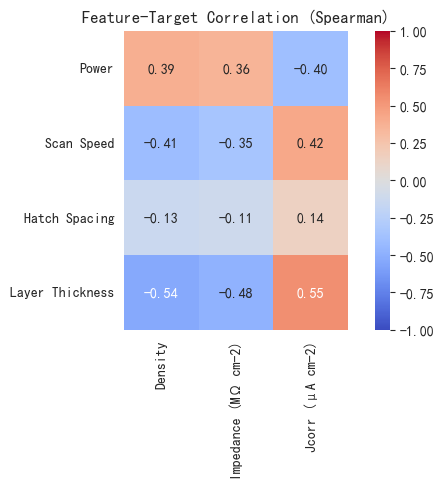

In [9]:
# ===== Cell: Correlation heatmaps with loop for different methods =====
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc("font", family="SimHei")  # 中文显示设置

# 特征与目标列
# === 中英文映射 ===
col_map = {
    '功率': 'Power',
    '扫描速度': 'Scan Speed',
    '扫描间隙': 'Hatch Spacing',
    '层厚': 'Layer Thickness',
    '致密度': 'Density',
    '阻抗(MΩ cm-2)': 'Impedance (MΩ cm-2)',
    'Jcorr\n(μA cm-2)': 'Jcorr (μA cm-2)'
}

X_cols = list(col_map.keys())[:4]   # 中文特征列
y_cols = list(col_map.keys())[4:]   # 中文目标列

# 目录结构：model_plots/corr/
save_root = "active_learning/old/plots"
corr_dir = os.path.join(save_root, "corr")
os.makedirs(corr_dir, exist_ok=True)

# 定义要使用的相关性计算方法
methods = ["pearson", "spearman"]

for method in methods:
    # 1) X vs X 相关热力图（特征之间）
    corr_xx = df[X_cols].corr(method=method)
    corr_xx.rename(index=col_map, columns=col_map, inplace=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_xx, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f", square=True)
    plt.title(f"Feature-Feature Correlation ({method.capitalize()})")
    plt.tight_layout()
    plt.savefig(os.path.join(corr_dir, f"X_X_corr_{method}.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # 2) X vs y 相关热力图（特征与各目标）
    # 拼接后做相关矩阵，再抽取 X 对 y 的子块
    df_xy = pd.concat([df[X_cols], df[y_cols]], axis=1)
    corr_xy = df_xy.corr(method=method).loc[X_cols, y_cols]
    corr_xy.rename(index=col_map, columns=col_map, inplace=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_xy, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f", square=True)
    plt.title(f"Feature-Target Correlation ({method.capitalize()})")
    plt.tight_layout()
    plt.savefig(os.path.join(corr_dir, f"X_y_corr_{method}.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Excel 文件路径
    excel_path = os.path.join(corr_dir, f"correlation_{method}.xlsx")

    # 用 ExcelWriter 写入两个 sheet
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        # 特征间相关矩阵
        corr_xx.to_excel(writer, sheet_name="X_vs_X")
        # 特征-目标相关矩阵
        corr_xy.to_excel(writer, sheet_name="X_vs_y")

## SHAP

In [11]:
# ===== Cell: SHAP (pipeline-level, model-agnostic, final version) =====
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from openpyxl import load_workbook, Workbook
from openpyxl.drawing.image import Image as XLImage

plt.rc("font", family="SimHei")

X_cols = ['功率', '扫描速度', '扫描间隙', '层厚']
y_cols = ['致密度', '阻抗(MΩ cm-2)', 'Jcorr\n(μA cm-2)']

save_root = "active_learning/old/plots"
shap_root = os.path.join(save_root, "shap")  #把 save_root 和 "shap" 拼接成一个新的路径，
#即在 "model_plots" 目录下生成一个子目录路径 "model_plots/shap"，并把它赋值给变量 shap_root
os.makedirs(shap_root, exist_ok=True)  #os.makedirs 用来创建目录（包括必要的父目录），保证shap存在

# 建议选取一个小背景集，加速并稳定解释
X_bg = X_train.sample(min(100, len(X_train)), random_state=42)

for name, est in best_pipes.items():
    model_dir = os.path.join(shap_root, name)
    os.makedirs(model_dir, exist_ok=True)

    # 针对每个目标，构建单输出预测函数
    for idx, target in enumerate(y_cols):
        def f_pred(X):
            # X 为原始 DataFrame；管道会自动预处理
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=X_train.columns)
                # est.predict 返回形状 [n_samples, n_targets]，这里取第 idx 列，即取第idx个目标的预测值
            return est.predict(X)[:, idx]


        # 使用统一的 Explainer（会根据模型类型自动选择核）
        explainer = shap.Explainer(f_pred, X_bg)  #创建一个 SHAP 解释器，用 X_bg 作为参考基线，解释预测函数 f_pred 的输出
        #explainer(X_test) 会返回一个 shap.Explanation 对象，里面包含：
        # shap_values.values：每个样本、每个特征的 SHAP 值（即特征对预测的贡献），形状：(n_samples,n_features)
        #shap_values.base_values：基线预测值（即在没有任何特征信息时模型的期望输出）。
        # shap_values.data：对应的输入特征数据
        shap_values = explainer(X_test)

        # 1. SHAP 值 DataFrame
        shap_df = pd.DataFrame(
            shap_values.values,
            columns=[f"SHAP_{col}" for col in X_test.columns],
            index=X_test.index
        )

        # 2. 原始特征值 DataFrame
        data_df = pd.DataFrame(
            shap_values.data,
            columns=X_test.columns,
            index=X_test.index
        )

        # 3. 基线预测值
        base_df = pd.DataFrame(
            {"base_value": shap_values.base_values},
            index=X_test.index
        )

        # 4. 合并成一个总表
        out_df = pd.concat([data_df, shap_df, base_df], axis=1)

        # 5. 保存到 CSV
        fname = f"{target}_SHAP_values.csv".replace("\n", "")
        out_path = os.path.join(model_dir, fname)
        out_df.to_csv(out_path, encoding="utf-8-sig")

        # ===== 1. summary plot（条形图） =====
        #绘制 summary plot（蜜蜂图/beeswarm plot）
        shap.summary_plot(shap_values.values,  #含义：SHAP 值矩阵，形状为 (n_samples, n_features);作用：表示每个样本、每个特征对预测结果的贡献大小
                          X_test,  #用于在图中显示特征取值（比如 beeswarm 图里点的颜色就是由 X_test 的特征值决定的）
                          feature_names=list(X_test.columns),
                          #作用：在图的纵轴上标注每个特征的名称。默认：如果不传，SHAP 会尝试自动从 X_test 里获取列名；但显式传入更稳妥
                          plot_type="bar",  #指定绘图类型，bar表示制作条形图，不填则表示beeswarm
                          show=False  #True，会直接调用 plt.show()。这里设为 False：表示不立即显示，而是交给后续代码（比如 plt.savefig(...)）来保存图像
                          )
        plt.title(f"{name} - {target} 的 SHAP（bar）")
        plt.tight_layout()  #自动调整子图（subplot）之间的间距，避免标题、坐标轴标签、刻度文字等元素发生重叠
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_bar.png".replace("\n", "")), dpi=300, bbox_inches="tight")
        plt.close(plt.gcf())

        # ===== 2. 蜜蜂图（beeswarm） =====
        shap.summary_plot(shap_values.values, X_test, feature_names=list(X_test.columns), show=False)
        plt.title(f"{name} - {target} 的 SHAP（beeswarm）")
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_beeswarm.png".replace("\n", "")), dpi=300,
                    bbox_inches="tight")
        plt.close(plt.gcf())

        # ===== 3. 单特征依赖图 =====
        for feat in X_cols:
            if feat in X_test.columns:
                shap.dependence_plot(feat, shap_values.values, X_test, show=False)
                plt.title(f"{name} - {target} - {feat} 的 SHAP 依赖图")
                plt.tight_layout()
                plt.savefig(os.path.join(model_dir, f"{target}_SHAP_dep_{feat}.png".replace("\n", "")), dpi=300,
                            bbox_inches="tight")
                plt.close(plt.gcf())

        # ===== 4. 决策图（decision plot） =====
        # 判断 base_values 的维度，兼容单输出和多输出
        # if shap_values.base_values.ndim == 1:
        #     base_val = np.mean(shap_values.base_values)  # 用平均基准值（标量）
        #     shap_val = shap_values.values
        # else:
        #     base_val = np.mean(shap_values.base_values[:, idx])  # 多输出时取第 idx 个目标的平均基准值
        #     shap_val = shap_values.values[:, :, idx]

        base_val = np.mean(shap_values.base_values)  # 用平均基准值（标量）
        shap_val = shap_values.values
        # 只画前 50 个样本，避免太乱
        shap.decision_plot(
            base_val,
            #shap_val[:50],
            shap_val,
            #features=X_test.iloc[:50],#iloc 是 pandas 库里用来做 基于位置的索引 的方法，全称是 index location。它允许你通过“行号”和“列号”来选取数据，而不是通过标签（列名或行索引名）
            features=X_test,  #loc 按标签（行名、列名）
            feature_names=list(X_test.columns),
            show=False
        )
        #plt.title(f"{name} - {target} 的 SHAP 决策图（前50样本）")
        plt.title(f"{name} - {target} 的 SHAP 决策图")
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_decision.png".replace("\n", "")), dpi=300,
                    bbox_inches="tight")
        plt.close(plt.gcf())

# 遍历 shap_root 下的每个模型目录
for name in best_pipes.keys():
    model_dir = os.path.join(shap_root, name)
    excel_path = os.path.join(model_dir, f"{name}_SHAP.xlsx")

    # 如果文件不存在，新建一个
    if not os.path.exists(excel_path):
        wb = Workbook()
        wb.save(excel_path)

    wb = load_workbook(excel_path)

    # 遍历每个目标
    for target in y_cols:
        sheet_name = target.replace("\n", "_")
        if sheet_name in wb.sheetnames:
            ws = wb[sheet_name]
        else:
            ws = wb.create_sheet(sheet_name)

        # 要插入的图片文件列表
        fig_files = [
            f"{target}_SHAP_bar.png".replace("\n", ""),
            f"{target}_SHAP_beeswarm.png".replace("\n", "")
        ]

        # 添加依赖图
        fig_files.extend([
            f"{target}_SHAP_dep_{feat}.png".replace("\n", "")
            for feat in X_cols
            if os.path.exists(os.path.join(model_dir, f"{target}_SHAP_dep_{feat}.png".replace("\n", "")))
        ])

        # 添加决策图
        fig_files.append(f"{target}_SHAP_decision.png".replace("\n", ""))

        # 插入图片
        row = 2
        for fig in fig_files:
            fig_path = os.path.join(model_dir, fig)
            if os.path.exists(fig_path):
                img = XLImage(fig_path)
                img.width, img.height = 480, 320  # 调整大小
                ws.add_image(img, f"A{row}")
                row += 20  # 每张图隔开一些行

    wb.save(excel_path)

## 主动学习阶段

### 数据准备

In [10]:
import numpy as np
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import  mean_absolute_error
from sklearn.cluster import KMeans
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from xgboost import XGBRegressor

# 1) 读取候选池（只用工艺特征参与训练）
cand = pd.read_excel("removed_by_ED_bin.xlsx")

feature_cols = ["功率","扫描速度","扫描间隙","层厚"]
y_cols = ["致密度","阻抗(MΩ cm-2)","Jcorr\n(μA cm-2)"]

# 2) 已有的训练数据与最优管道
committee = [best_pipes["RandomForest"], best_pipes["XGBoost"], best_pipes["LightGBM"]]

# 3) 评价记录（用于停止条件）
history = {
    "R2_train": [], "MAE_train": [], "RMSE_train": [],
    "R2_test": [], "MAE_test": [], "RMSE_test": []
}

### 价值函数：
  委员会分歧+边界加权

In [11]:
TARGET_WEIGHTS = np.array([0.5, 0.3, 0.2])  # 致密度、阻抗、Jcorr 的权重

def committee_uncertainty(models, X_candidates):
    preds = [m.predict(X_candidates.values) for m in models]  # list of (n, n_targets)
    P = np.stack(preds, axis=0)                               # (n_models, n, n_targets)
    mu = P.mean(axis=2, keepdims=True)
    sd = P.std(axis=2, keepdims=True) + 1e-8
    Pz = (P - mu) / sd
    var = Pz.var(axis=0)                                      # (n, n_targets)
    w = TARGET_WEIGHTS[None, :]
    return (var * w).sum(axis=1)                              # (n,)

def boundary_weight(candidate_df):
    ed = candidate_df["能量密度"].values
    binlab = candidate_df["ED_bin"].values
    w = np.ones(len(candidate_df), dtype=float)
    near_76 = (binlab == "Mid") & (np.abs(ed - 80) <= 3)
    near_100 = (binlab == "Mid") & (np.abs(ed - 110) <= 3)
    w[near_76] *= 1.3
    w[near_100] *= 1.3
    high_mask = (binlab == "High")
    if high_mask.any():
        thr = np.percentile(ed[high_mask], 90)
        extreme = high_mask & (ed >= thr)
        w[extreme] *= 1.2
    return w

def value_function(models, X_candidates, candidate_df):
    base = committee_uncertainty(models, X_candidates)
    return base * boundary_weight(candidate_df)


### 配额+多样性+分段选点：
配额：每段至少 1 个；可按分段误差动态加配额。

多样性：在 Top-unc 中聚类，每簇取分数最高者，避免选到非常相似的点。

分段选点：独立计算分数并筛选，返回全局索引。

In [12]:
def allocate_quota_by_bin(candidate_df, base_per_bin=1, extra_by_error=None):
    quotas = {"Low": base_per_bin, "Mid": base_per_bin, "High": base_per_bin}
    if extra_by_error:
        worst_bin = max(extra_by_error, key=extra_by_error.get)
        quotas[worst_bin] += 1
    return quotas

def diversify_batch(X_candidates, scores, quota, random_state=42):
    if quota <= 0:
        return []
    idx_sorted = np.argsort(scores)[::-1]
    top_k = max(quota * 2, quota)
    idx_top = idx_sorted[:min(top_k, len(idx_sorted))]
    X_top = X_candidates.iloc[idx_top]
    k = min(quota, len(X_top))
    if k <= 0:
        return []
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10).fit(X_top.values)
    picks = []
    for c in range(k):
        cluster_idx = np.where(km.labels_ == c)[0]
        local_indices = idx_top[cluster_idx]
        local_scores = scores[local_indices]
        picks.append(local_indices[np.argmax(local_scores)])
    return picks

def select_points(models, candidate_df, feature_cols, quotas):
    selected_idx = []
    for binlab, q in quotas.items():
        pool_bin = candidate_df[candidate_df["ED_bin"] == binlab]
        if len(pool_bin) == 0 or q <= 0:
            continue
        X_bin = pool_bin[feature_cols]
        scores = value_function(models, X_bin, pool_bin)
        picks = diversify_batch(X_bin, scores, quota=min(q, len(pool_bin)))
        selected_idx.extend(pool_bin.index.values[picks].tolist())
    return selected_idx


### 模型进行贝叶斯调参+评估

In [13]:
def bayes_tune_model(model_name, X_train, y_train, cv=3, n_iter=30, random_state=42):
    """
    对 RandomForest / XGBoost / LightGBM 进行贝叶斯优化调参
    返回最优管道和参数
    """
    if model_name == "RandomForest":
        base = RandomForestRegressor(random_state=random_state, n_jobs=-1)
        search_space = {
            "estimator__n_estimators": Integer(100, 600),
            "estimator__max_depth": Integer(3, 20),
            "estimator__min_samples_split": Integer(2, 20),
            "estimator__min_samples_leaf": Integer(1, 10),
            "estimator__max_features": Real(0.5, 1.0)
        }

    elif model_name == "XGBoost":
        base = XGBRegressor(random_state=random_state, n_jobs=-1, tree_method="hist", eval_metric="rmse")
        search_space = {
            "estimator__n_estimators": Integer(100, 600),
            "estimator__max_depth": Integer(3, 10),
            "estimator__learning_rate": Real(1e-3, 0.3, prior="log-uniform"),
            "estimator__subsample": Real(0.5, 1.0),
            "estimator__colsample_bytree": Real(0.5, 1.0),
            "estimator__reg_lambda": Real(1e-3, 10.0, prior="log-uniform"),
            "estimator__reg_alpha": Real(1e-6, 1.0, prior="log-uniform")
        }

    elif model_name == "LightGBM":
        base = LGBMRegressor(random_state=random_state, n_jobs=-1)
        search_space = {
            "estimator__n_estimators": Integer(100, 600),
            "estimator__max_depth": Integer(-1, 15),  # -1 表示不限制
            "estimator__learning_rate": Real(1e-3, 0.3, prior="log-uniform"),
            "estimator__num_leaves": Integer(20, 200),
            "estimator__subsample": Real(0.5, 1.0),
            "estimator__colsample_bytree": Real(0.5, 1.0),
            "estimator__reg_lambda": Real(1e-3, 10.0, prior="log-uniform"),
            "estimator__reg_alpha": Real(1e-6, 1.0, prior="log-uniform")
        }

    else:
        raise ValueError("Unsupported model name")

    pipe = MultiOutputRegressor(base)

    opt_cv = BayesSearchCV(
        estimator=pipe,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring="r2",
        random_state=random_state,
        n_jobs=-1,
        refit=True
    )
    opt_cv.fit(X_train, y_train)
    return opt_cv.best_estimator_, opt_cv.best_params_

def evaluate_model_all(model, X_eval, y_eval):
    y_pred = model.predict(X_eval.values)
    r2_avg   = r2_score(y_eval.values, y_pred, multioutput="uniform_average")
    mae_avg  = mean_absolute_error(y_eval.values, y_pred, multioutput="uniform_average")
    rmse_avg = np.sqrt(mean_squared_error(y_eval.values, y_pred, multioutput="uniform_average"))
    r2_each   = r2_score(y_eval.values, y_pred, multioutput="raw_values")
    mae_each  = mean_absolute_error(y_eval.values, y_pred, multioutput="raw_values")
    rmse_each = np.sqrt(mean_squared_error(y_eval.values, y_pred, multioutput="raw_values"))
    return {
        "R2_avg": r2_avg, "MAE_avg": mae_avg, "RMSE_avg": rmse_avg,
        "R2_each": dict(zip(y_eval.columns, r2_each)),
        "MAE_each": dict(zip(y_eval.columns, mae_each)),
        "RMSE_each": dict(zip(y_eval.columns, rmse_each))
    }

### 主动学习循环

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置保存目录
save_dir = "active_learning"
os.makedirs(save_dir, exist_ok=True)

models_to_run = ["RandomForest", "XGBoost", "LightGBM"]

max_rounds = 5
base_quota_per_bin = 1

min_improve_r2 = 0.01
min_drop_mae   = 0.03
min_drop_rmse  = 0.03

for model_name in models_to_run:
    print(f"\n=== 开始 {model_name} 主动学习循环 ===")

    # 初始化训练集和候选池（注意：这里要用原始的 X_train, y_train, cand 副本，避免互相污染）
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()
    cand_model = cand.copy()

    history = {
        "R2_train": [], "MAE_train": [], "RMSE_train": [],
        "R2_test": [], "MAE_test": [], "RMSE_test": []
    }
    no_improve_rounds = 0

    # Excel 文件路径
    excel_path = os.path.join(save_dir, f"{model_name}_results.xlsx")
    writer = pd.ExcelWriter(excel_path, engine="xlsxwriter")

    for r in range(1, max_rounds + 1):
        print(f"\n=== {model_name} Round {r} ===")

        if r == 5:
            # 读取 round5.xlsx 文件
            round5_data = pd.read_excel("round5.xlsx")
            added_df = round5_data
            print(f"第 5 轮直接使用 round5.xlsx 中的数据，选入样本数：{len(added_df)}")
        else:
            quotas = allocate_quota_by_bin(cand_model, base_per_bin=base_quota_per_bin)
            selected_idx = select_points([best_pipes[model_name]], cand_model, feature_cols, quotas)
            if len(selected_idx) == 0:
                print("无可选点或配额为 0，停止。")
                break

            added_df = cand_model.loc[selected_idx]
            print(f"选入样本数：{len(added_df)} | Low/Mid/High 分布：",
                  added_df["ED_bin"].value_counts().to_dict())

            # 更新候选池
            cand_model = cand_model.drop(index=selected_idx)

        # 更新训练集
        X_train_model = pd.concat([X_train_model, added_df[feature_cols]], ignore_index=True)
        y_train_model = pd.concat([y_train_model, added_df[y_cols]], ignore_index=True)

        # 调参
        best_model, best_params = bayes_tune_model(model_name, X_train_model, y_train_model, cv=3, n_iter=30)
        print(f"{model_name} 最优参数：", best_params)

        best_pipes[model_name] = best_model
        # === 评估训练集 ===
        metrics_train = evaluate_model_all(best_model, X_train_model, y_train_model)
        r2_train   = metrics_train["R2_avg"]
        mae_train  = metrics_train["MAE_avg"]
        rmse_train = metrics_train["RMSE_avg"]

        # === 评估测试集 ===
        metrics_test = evaluate_model_all(best_model, X_test, y_test)
        r2_test   = metrics_test["R2_avg"]
        mae_test  = metrics_test["MAE_avg"]
        rmse_test = metrics_test["RMSE_avg"]

        history["R2_train"].append(r2_train)
        history["MAE_train"].append(mae_train)
        history["RMSE_train"].append(rmse_train)
        history["R2_test"].append(r2_test)
        history["MAE_test"].append(mae_test)
        history["RMSE_test"].append(rmse_test)

        print(f"{model_name} 表现: Train R2={r2_train:.4f}, MAE={mae_train:.4f}, RMSE={rmse_train:.4f} | "
              f"Test R²={r2_test:.4f}, MAE={mae_test:.4f}, RMSE={rmse_test:.4f}")
        # === 保存到 Excel ===
        added_df.to_excel(writer, sheet_name=f"Round{r}", index=False)

        perf_df = pd.DataFrame({
            "Model": [model_name],
            "Round": [r],
            "R2_train": [r2_train],
            "MAE_train": [mae_train],
            "RMSE_train": [rmse_train],
            "R2_test": [r2_test],
            "MAE_test": [mae_test],
            "RMSE_test": [rmse_test],
            "Params": [best_params]
        })
        perf_df.to_excel(writer, sheet_name=f"Round{r}_Perf", index=False)

        # === 在测试集上预测并保存 ===
        # 可以选择全部测试集或子集
        N = 10  # 每轮只保存前10条
        X_test_subset = X_test.iloc[:N].copy()
        y_test_subset = y_test.iloc[:N].copy()

        y_pred = best_model.predict(X_test_subset)

        pred_df = pd.DataFrame(
            np.hstack([y_test_subset.values, y_pred]),
            columns=[
                "True_致密度", "True_阻抗", "True_Jcorr",
                "Pred_致密度", "Pred_阻抗", "Pred_Jcorr"
            ]
        )
        pred_df.to_excel(writer, sheet_name=f"Round{r}_Pred", index=False)
        # 停止条件判断
        if len(history["R2_test"]) >= 2:
            r2_gain   = history["R2_test"][-1]   - history["R2_test"][-2]
            mae_drop  = history["MAE_test"][-2]  - history["MAE_test"][-1]
            rmse_drop = history["RMSE_test"][-2] - history["RMSE_test"][-1]

            insufficient = (
                (r2_gain  < min_improve_r2) and
                (mae_drop < min_drop_mae)   and
                (rmse_drop < min_drop_rmse)
            )
            no_improve_rounds = no_improve_rounds + 1 if insufficient else 0

        if no_improve_rounds >= 2:
            print(f"{model_name}: 连续两轮增益不足，停止主动学习。")
            break

        if len(cand_model) == 0:
            print(f"{model_name}: 候选池耗尽，停止主动学习。")
            break

    # 循环结束后，保存历史性能
    history_df = pd.DataFrame({
        "Round": list(range(1, len(history["R2_train"]) + 1)),
        "R2_train": history["R2_train"],
        "MAE_train": history["MAE_train"],
        "RMSE_train": history["RMSE_train"],
        "R2_test": history["R2_test"],
        "MAE_test": history["MAE_test"],
        "RMSE_test": history["RMSE_test"]
    })
    history_df.to_excel(writer, sheet_name="History", index=False)

    writer.close()
    print(f"{model_name} 的结果已保存到 {excel_path}")
    #  绘制收敛曲线
    plot_dir = os.path.join(save_dir, "plots")
    os.makedirs(plot_dir, exist_ok=True)

    plt.figure(figsize=(8, 6))
    plt.plot(history_df["Round"], history_df["R2_train"], marker="o", label="Train R2", color="blue")
    plt.plot(history_df["Round"], history_df["R2_test"], marker="o", label="Test R2", color="cyan")

    plt.plot(history_df["Round"], history_df["MAE_train"], marker="s", label="Train MAE", color="red")
    plt.plot(history_df["Round"], history_df["MAE_test"], marker="s", label="Test MAE", color="orange")

    plt.plot(history_df["Round"], history_df["RMSE_train"], marker="^", label="Train RMSE", color="green")
    plt.plot(history_df["Round"], history_df["RMSE_test"], marker="^", label="Test RMSE", color="lime")

    plt.xlabel("Round")
    plt.ylabel("Metric Value")
    plt.title(f"{model_name} Active Learning Convergence Trend")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plot_path = os.path.join(plot_dir, f"{model_name}_convergence_trend.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"{model_name} 收敛趋势图已保存到: {plot_path}")


=== 开始 RandomForest 主动学习循环 ===

=== RandomForest Round 1 ===
选入样本数：3 | Low/Mid/High 分布： {'Low': 1, 'Mid': 1, 'High': 1}


D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Rand

RandomForest 最优参数： OrderedDict({'estimator__max_depth': 14, 'estimator__max_features': 0.7580144948953719, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 596})


D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Rand

RandomForest 表现: Train R2=0.9834, MAE=0.3309, RMSE=0.7776 | Test R²=0.8857, MAE=0.8886, RMSE=1.9389

=== RandomForest Round 2 ===


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 108, number of used features: 4
[LightGBM] [Info] Start training from score 88.708333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 111, number of used features: 4
[LightGBM] [Info] Start training from score 88.799099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\MachineLearning\data_cleaner\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with featur

LightGBM 收敛趋势图已保存到: active_learning\plots\LightGBM_convergence_trend.png


In [15]:
# 保存模型结果
results = {}

#仅保留需要的三个模型
selected_models = ["RandomForest", "XGBoost", "LightGBM"]
best_pipes_filtered = {name: best_pipes[name] for name in selected_models if name in best_pipes}

# 用新的过滤后的best_pipes覆盖原来的best_pipes
best_pipes = best_pipes_filtered


for model_name, best_model in best_pipes.items():
    # 用最终模型在测试集上预测
    y_pred = best_model.predict(X_test)

    # ---- 整体平均指标 ----
    rmse_avg = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="uniform_average"))
    mae_avg = mean_absolute_error(y_test, y_pred, multioutput="uniform_average")
    r2_avg = r2_score(y_test, y_pred, multioutput="uniform_average")

    # ---- 每个输出单独指标 ----
    rmse_each = np.sqrt(mean_squared_error(y_test, y_pred, multioutput="raw_values"))
    mae_each = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
    r2_each = r2_score(y_test, y_pred, multioutput="raw_values")

    # 保存结果到字典
    results[model_name] = {
        "Best Params": best_model.get_params(),   # 或者保存你调参时的 best_params
        "RMSE_avg": rmse_avg,
        "MAE_avg": mae_avg,
        "R2_avg": r2_avg,
        "RMSE_each": dict(zip(y_test.columns, rmse_each)),
        "MAE_each": dict(zip(y_test.columns, mae_each)),
        "R2_each": dict(zip(y_test.columns, r2_each))
    }

# 转成 DataFrame 展开保存
rows = []
for model, metrics in results.items():
    row = {
        "Model": model,
        "Best Params": str(metrics["Best Params"]),
        "RMSE_avg": metrics["RMSE_avg"],
        "MAE_avg": metrics["MAE_avg"],
        "R2_avg": metrics["R2_avg"],
    }
    for col in metrics["R2_each"].keys():
        row[f"RMSE_{col}"] = metrics["RMSE_each"][col]
        row[f"MAE_{col}"] = metrics["MAE_each"][col]
        row[f"R2_{col}"] = metrics["R2_each"][col]
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_excel("final_model_results.xlsx", index=False)
#打印模型结果
for name, res in results.items():
    print(f"\n模型: {name}")
    print(f"最优参数: {res['Best Params']}")
    print(f"整体平均指标 -> R2_avg: {res['R2_avg']:.3f}, RMSE_avg: {res['RMSE_avg']:.3f}, MAE_avg: {res['MAE_avg']:.3f}")

    # 打印逐目标指标
    print("逐目标指标：")
    for col in res["R2_each"].keys():
        r2_val   = res["R2_each"][col]
        rmse_val = res["RMSE_each"][col]
        mae_val  = res["MAE_each"][col]
        print(f"  {col}: R2={r2_val:.3f}, RMSE={rmse_val:.3f}, MAE={mae_val:.3f}")



模型: RandomForest
最优参数: {'estimator__bootstrap': True, 'estimator__ccp_alpha': 0.0, 'estimator__criterion': 'squared_error', 'estimator__max_depth': 13, 'estimator__max_features': 0.8906930406520348, 'estimator__max_leaf_nodes': None, 'estimator__max_samples': None, 'estimator__min_impurity_decrease': 0.0, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__min_weight_fraction_leaf': 0.0, 'estimator__monotonic_cst': None, 'estimator__n_estimators': 310, 'estimator__n_jobs': -1, 'estimator__oob_score': False, 'estimator__random_state': 42, 'estimator__verbose': 0, 'estimator__warm_start': False, 'estimator': RandomForestRegressor(max_depth=13, max_features=0.8906930406520348,
                      n_estimators=310, n_jobs=-1, random_state=42), 'n_jobs': None}
整体平均指标 -> R2_avg: 0.874, RMSE_avg: 2.040, MAE_avg: 0.930
逐目标指标：
  致密度: R2=0.917, RMSE=3.533, MAE=2.743
  阻抗(MΩ cm-2): R2=0.780, RMSE=0.036, MAE=0.029
  Jcorr
(μA cm-2): R2=0.925, RMSE=0.029, MAE=0.020



In [16]:
#预测round5
# 读取 round5.xlsx 文件
round5_data = pd.read_excel("round5.xlsx")

# 假设特征列与之前相同
feature_cols = ["功率", "扫描速度", "扫描间隙", "层厚"]

# 提取特征数据
X_round5 = round5_data[feature_cols]

# 创建一个空的DataFrame来存放预测结果
predictions_df = round5_data.copy()

# 对每个模型进行预测
for model_name, model in best_pipes.items():
    # 预测
    y_pred = model.predict(X_round5)

    # 添加预测值到DataFrame中
    predictions_df[f"{model_name}_致密度"] = y_pred[:, 0]
    predictions_df[f"{model_name}_阻抗(MΩ cm-2)"] = y_pred[:, 1]
    predictions_df[f"{model_name}_Jcorr(μA cm-2)"] = y_pred[:, 2]

# 保存结果到新的Excel文件
output_file = "round5_predictions_with_original_data.xlsx"
predictions_df.to_excel(output_file, index=False)

print(f"预测结果已保存至 {output_file}")


预测结果已保存至 round5_predictions_with_original_data.xlsx


In [18]:
save_dir = "active_learning"
models_to_run = ["RandomForest", "XGBoost", "LightGBM"]

# 遍历三个模型的结果文件
for model_name in models_to_run:
    excel_path = os.path.join(save_dir, f"{model_name}_results.xlsx")
    if not os.path.exists(excel_path):
        print(f"{excel_path} 不存在，跳过。")
        continue

    print(f"处理 {model_name} 的结果文件...")

    # 读取已有文件
    xls = pd.ExcelFile(excel_path)

    # 找到所有 Round{r}_Pred sheet
    pred_sheets = [s for s in xls.sheet_names if s.endswith("_Pred")]

    # 新文件路径
    new_path = os.path.join(save_dir, f"{model_name}_results_with_features.xlsx")
    writer = pd.ExcelWriter(new_path, engine="xlsxwriter")

    for sheet in pred_sheets:
        # 读取原有预测结果
        pred_df = pd.read_excel(xls, sheet_name=sheet)

        # 保持行数一致，从 X_test 取前 N 行特征
        N = len(pred_df)
        X_test_subset = X_test.iloc[:N][['功率','扫描速度','扫描间隙','层厚']].reset_index(drop=True)

        # 拼接：特征 + 原预测表
        merged_df = pd.concat([X_test_subset, pred_df], axis=1)

        # 保存到新文件
        merged_df.to_excel(writer, sheet_name=sheet, index=False)

    # 其他 sheet 原样复制过去
    for sheet in xls.sheet_names:
        if sheet not in pred_sheets:
            df = pd.read_excel(xls, sheet_name=sheet)
            df.to_excel(writer, sheet_name=sheet, index=False)

    writer.close()
    print(f"{model_name} 的新文件已生成：{new_path}")


处理 RandomForest 的结果文件...
RandomForest 的新文件已生成：active_learning\RandomForest_results_with_features.xlsx
处理 XGBoost 的结果文件...
XGBoost 的新文件已生成：active_learning\XGBoost_results_with_features.xlsx
处理 LightGBM 的结果文件...
LightGBM 的新文件已生成：active_learning\LightGBM_results_with_features.xlsx


In [19]:
save_dir = "active_learning"
models_to_run = ["RandomForest", "XGBoost", "LightGBM"]

# 定义字典存储最终数据
final_data = {}

for model_name in models_to_run:
    excel_path = os.path.join(save_dir, f"{model_name}_results.xlsx")
    print(f"读取 {excel_path} ...")

    # 读取所有 sheet
    xls = pd.ExcelFile(excel_path)
    # 只取 Round{r} 的数据，不包括 Perf/Pred
    round_sheets = [s for s in xls.sheet_names if s.startswith("Round") and not s.endswith("_Perf") and not s.endswith("_Pred")]

    # 拼接所有 Round{r} 的数据
    new_train_df = pd.concat([pd.read_excel(xls, sheet_name=s) for s in round_sheets], ignore_index=True)

    # 合并原始训练数据和新加入的数据
    orig_train_df = pd.concat([X_train, y_train], axis=1)  # 原始训练数据（特征+目标）
    full_train_df = pd.concat([orig_train_df, new_train_df], ignore_index=True)

    # 存入字典
    final_data[model_name] = {
        "train_df": full_train_df,   # 完整训练集（原始+新加入）
        "X_test": X_test.copy(),
        "y_test": y_test.copy()
    }

# 查看结果
for model_name, data in final_data.items():
    print(f"{model_name} 最终训练集大小: {data['train_df'].shape}, 测试集大小: {data['X_test'].shape}")


读取 active_learning\RandomForest_results.xlsx ...
读取 active_learning\XGBoost_results.xlsx ...
读取 active_learning\LightGBM_results.xlsx ...
RandomForest 最终训练集大小: (105, 9), 测试集大小: (24, 4)
XGBoost 最终训练集大小: (111, 9), 测试集大小: (24, 4)
LightGBM 最终训练集大小: (111, 9), 测试集大小: (24, 4)


## 性能可视化

In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="SimHei")

# 中文列名 -> 英文显示名映射
target_map = {
    '致密度': 'Density',
    '阻抗(MΩ cm-2)': 'Impedance (MΩ cm-2)',
    'Jcorr\n(μA cm-2)': 'Jcorr (μA cm-2)'
}

# 保存目录
save_dir = "active_learning/plots"
os.makedirs(save_dir, exist_ok=True)

# 遍历目标变量
for col, label in target_map.items():
    # 遍历模型
    for model_name, data in final_data.items():
        # 获取最终训练数据和测试数据
        X_train_full = data["train_df"][feature_cols]
        y_train_full = data["train_df"][[col]]
        X_test = data["X_test"]
        y_test = data["y_test"][[col]]

        # 获取模型
        model = best_pipes[model_name]

        # 预测
        y_pred_train = model.predict(X_train_full)
        y_pred_test = model.predict(X_test)

        # 如果是多目标预测，取对应列索引
        idx = list(y.columns).index(col)
        if y_pred_train.ndim > 1:
            y_pred_train_col = y_pred_train[:, idx]
            y_pred_test_col = y_pred_test[:, idx]
        else:
            y_pred_train_col = y_pred_train
            y_pred_test_col = y_pred_test

        # 绘制散点图
        plt.figure(figsize=(5, 5), dpi=300)
        sns.scatterplot(x=y_train_full[col].values, y=y_pred_train_col,
                        color='green', label='Train', alpha=0.6, s=30)
        sns.scatterplot(x=y_test[col].values, y=y_pred_test_col,
                        color='magenta', label='Test', alpha=0.9, s=40)

        # 对角线
        all_vals = np.concatenate([y_train_full[col].values, y_pred_train_col,
                                   y_test[col].values, y_pred_test_col])
        lims = [all_vals.min(), all_vals.max()]
        plt.plot(lims, lims, 'k--', label='Diagonal line')

        plt.xlabel("Measured")
        plt.ylabel("Predicted")
        plt.title(f"{model_name} - {label}")

        # 计算指标
        r2_train = r2_score(y_train_full[col].values, y_pred_train_col)
        rmse_train = np.sqrt(mean_squared_error(y_train_full[col].values, y_pred_train_col))
        r2_test = r2_score(y_test[col].values, y_pred_test_col)
        rmse_test = np.sqrt(mean_squared_error(y_test[col].values, y_pred_test_col))

        # 在图上显示
        ypos = 0.95
        plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}", transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}", transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}", transform=plt.gca().transAxes, va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}", transform=plt.gca().transAxes, va='top', color="magenta")

        plt.legend()

        # 保存图像与数据
        model_dir = os.path.join(save_dir, "scatter", model_name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{model_name}_{label}".replace("/", "-")
        png_path = os.path.join(model_dir, base_fn + "_scatter.png")
        excel_path = os.path.join(model_dir, base_fn + "_scatter.xlsx")
        plt.savefig(png_path, bbox_inches="tight")
        plt.close()

        # 保存散点数据
        df_scatter = pd.DataFrame({
            "Measured": np.concatenate([y_train_full[col].values, y_test[col].values]),
            "Predicted": np.concatenate([y_pred_train_col, y_pred_test_col]),
            "Split": ["Train"] * len(y_train_full) + ["Test"] * len(y_test),
            "Target": label
        })
        df_scatter.to_excel(excel_path, index=False)

        print(f"{model_name} - {label} 散点图和数据已保存到 {model_dir}")


RandomForest - Density 散点图和数据已保存到 active_learning/plots\scatter\RandomForest
XGBoost - Density 散点图和数据已保存到 active_learning/plots\scatter\XGBoost
LightGBM - Density 散点图和数据已保存到 active_learning/plots\scatter\LightGBM
RandomForest - Impedance (MΩ cm-2) 散点图和数据已保存到 active_learning/plots\scatter\RandomForest
XGBoost - Impedance (MΩ cm-2) 散点图和数据已保存到 active_learning/plots\scatter\XGBoost
LightGBM - Impedance (MΩ cm-2) 散点图和数据已保存到 active_learning/plots\scatter\LightGBM
RandomForest - Jcorr (μA cm-2) 散点图和数据已保存到 active_learning/plots\scatter\RandomForest
XGBoost - Jcorr (μA cm-2) 散点图和数据已保存到 active_learning/plots\scatter\XGBoost
LightGBM - Jcorr (μA cm-2) 散点图和数据已保存到 active_learning/plots\scatter\LightGBM


In [21]:
# ======残差=========
for col, label in target_map.items():   # 遍历目标
    for model_name, data in final_data.items():   # 遍历模型
        # 获取训练集和测试集
        X_train_full = data["train_df"][feature_cols]
        y_train_full = data["train_df"][[col]]
        X_test = data["X_test"]
        y_test = data["y_test"][[col]]

        # 获取模型
        model = best_pipes[model_name]

        # 预测
        y_pred_train = model.predict(X_train_full)
        y_pred_test = model.predict(X_test)

        # 如果是多目标预测，取对应列索引
        idx = list(y.columns).index(col)
        if y_pred_train.ndim > 1:
            y_pred_train_col = y_pred_train[:, idx]
            y_pred_test_col = y_pred_test[:, idx]
        else:
            y_pred_train_col = y_pred_train
            y_pred_test_col = y_pred_test

        # 计算残差
        residuals_train = y_train_full[col].values - y_pred_train_col
        residuals_test = y_test[col].values - y_pred_test_col

        # 绘制残差散点图
        plt.figure(figsize=(5, 5), dpi=300)
        sns.scatterplot(x=y_pred_train_col, y=residuals_train,
                        color='green', label='Train', alpha=0.6, s=30)
        sns.scatterplot(x=y_pred_test_col, y=residuals_test,
                        color='magenta', label='Test', alpha=0.9, s=40)

        plt.axhline(0, color='red', linestyle='--')  # 理想残差线 y=0
        plt.xlabel("Predicted")
        plt.ylabel("Residual")
        plt.title(f"{model_name} - {label} Residuals")

        # 计算指标
        r2_train = r2_score(y_train_full[col].values, y_pred_train_col)
        rmse_train = np.sqrt(mean_squared_error(y_train_full[col].values, y_pred_train_col))
        r2_test = r2_score(y_test[col].values, y_pred_test_col)
        rmse_test = np.sqrt(mean_squared_error(y_test[col].values, y_pred_test_col))

        # 在图上显示
        ypos = 0.95
        plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}", transform=plt.gca().transAxes,
                       va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}", transform=plt.gca().transAxes,
                       va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}", transform=plt.gca().transAxes,
                       va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}", transform=plt.gca().transAxes,
                       va='top', color="magenta")

        plt.legend()

        # 保存图像与数据
        model_dir = os.path.join(save_dir, "residual", model_name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{model_name}_{label}".replace("/", "-")
        plt.savefig(os.path.join(model_dir, base_fn + "_residual_scatter.png"), bbox_inches="tight")
        plt.close()

        # 保存残差数据到 Excel
        df_residual = pd.DataFrame({
            "Predicted": np.concatenate([y_pred_train_col, y_pred_test_col]),
            "Residual": np.concatenate([residuals_train, residuals_test]),
            "Split": ["Train"] * len(y_pred_train_col) + ["Test"] * len(y_pred_test_col),
            "Target": label
        })
        df_residual.to_excel(os.path.join(model_dir, base_fn + "_residual_scatter.xlsx"), index=False)

        print(f"{model_name} - {label} 残差图和数据已保存到 {model_dir}")


RandomForest - Density 残差图和数据已保存到 active_learning/plots\residual\RandomForest
XGBoost - Density 残差图和数据已保存到 active_learning/plots\residual\XGBoost
LightGBM - Density 残差图和数据已保存到 active_learning/plots\residual\LightGBM
RandomForest - Impedance (MΩ cm-2) 残差图和数据已保存到 active_learning/plots\residual\RandomForest
XGBoost - Impedance (MΩ cm-2) 残差图和数据已保存到 active_learning/plots\residual\XGBoost
LightGBM - Impedance (MΩ cm-2) 残差图和数据已保存到 active_learning/plots\residual\LightGBM
RandomForest - Jcorr (μA cm-2) 残差图和数据已保存到 active_learning/plots\residual\RandomForest
XGBoost - Jcorr (μA cm-2) 残差图和数据已保存到 active_learning/plots\residual\XGBoost
LightGBM - Jcorr (μA cm-2) 残差图和数据已保存到 active_learning/plots\residual\LightGBM


In [22]:
# =========误差直方图=========
for col, label in target_map.items():   # 遍历目标
    for model_name, data in final_data.items():   # 遍历模型
        # 获取训练集和测试集
        X_train_full = data["train_df"][feature_cols]
        y_train_full = data["train_df"][[col]]
        X_test = data["X_test"]
        y_test = data["y_test"][[col]]

        # 获取模型
        model = best_pipes[model_name]

        # 预测
        y_pred_train = model.predict(X_train_full)
        y_pred_test = model.predict(X_test)

        # 如果是多目标预测，取对应列索引
        idx = list(y.columns).index(col)
        if y_pred_train.ndim > 1:
            y_pred_train_col = y_pred_train[:, idx]
            y_pred_test_col = y_pred_test[:, idx]
        else:
            y_pred_train_col = y_pred_train
            y_pred_test_col = y_pred_test

        # 计算残差
        residuals_train = y_train_full[col].values - y_pred_train_col
        residuals_test = y_test[col].values - y_pred_test_col

        # ---------- 误差分布直方图 / KDE ----------
        plt.figure(figsize=(5, 5), dpi=300)

        sns.histplot(
            residuals_train,
            bins=30,
            color='green',
            label='Train',
            stat='count',
            kde=True,
            alpha=0.4
        )
        sns.histplot(
            residuals_test,
            bins=30,
            color='magenta',
            label='Test',
            stat='count',
            kde=True,
            alpha=0.4
        )

        plt.xlabel("Residual")
        plt.ylabel("Count")
        plt.title(f"{model_name} - {label} Residual Distribution")

        # ---- 计算 Train/Test 指标 ----
        r2_train = r2_score(y_train_full[col].values, y_pred_train_col)
        rmse_train = np.sqrt(mean_squared_error(y_train_full[col].values, y_pred_train_col))
        r2_test = r2_score(y_test[col].values, y_pred_test_col)
        rmse_test = np.sqrt(mean_squared_error(y_test[col].values, y_pred_test_col))

        # ---- 在图上显示 ----
        ypos = 0.95
        plt.gca().text(0.05, ypos, f"Train R2 = {r2_train:.3f}",
                       transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Train RMSE = {rmse_train:.3f}",
                       transform=plt.gca().transAxes, va='top', color="green"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test R2 = {r2_test:.3f}",
                       transform=plt.gca().transAxes, va='top', color="magenta"); ypos -= 0.05
        plt.gca().text(0.05, ypos, f"Test RMSE = {rmse_test:.3f}",
                       transform=plt.gca().transAxes, va='top', color="magenta")

        plt.legend()

        # ---- 保存图像与数据 ----
        model_dir = os.path.join(save_dir, "hist", model_name)
        os.makedirs(model_dir, exist_ok=True)
        base_fn = f"{model_name}_{label}".replace("/", "-")
        plt.savefig(os.path.join(model_dir, base_fn + "_residual_hist.png"), bbox_inches="tight")
        plt.close()

        # ---- 保存残差数据到 Excel ----
        df_hist = pd.DataFrame({
            "Residual": np.concatenate([residuals_train, residuals_test]),
            "Split": ["Train"] * len(residuals_train) + ["Test"] * len(residuals_test),
            "Target": label
        })
        df_hist.to_excel(os.path.join(model_dir, base_fn + "_residual_hist.xlsx"), index=False)

        print(f"{model_name} - {label} 残差分布图和数据已保存到 {model_dir}")


RandomForest - Density 残差分布图和数据已保存到 active_learning/plots\hist\RandomForest
XGBoost - Density 残差分布图和数据已保存到 active_learning/plots\hist\XGBoost
LightGBM - Density 残差分布图和数据已保存到 active_learning/plots\hist\LightGBM
RandomForest - Impedance (MΩ cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\RandomForest
XGBoost - Impedance (MΩ cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\XGBoost
LightGBM - Impedance (MΩ cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\LightGBM
RandomForest - Jcorr (μA cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\RandomForest
XGBoost - Jcorr (μA cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\XGBoost
LightGBM - Jcorr (μA cm-2) 残差分布图和数据已保存到 active_learning/plots\hist\LightGBM


## 模型性能热力图（主动循环后）

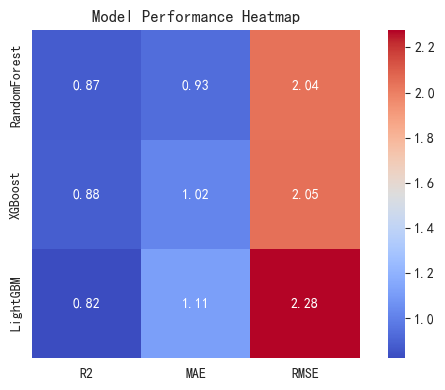

In [23]:
# ===== Cell: Model Performance Heatmap =====
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc("font", family="SimHei")  # 中文字体

perf_df = pd.DataFrame({
    model: {
        "R2": vals["R2_avg"],
        "MAE": vals["MAE_avg"],
        "RMSE": vals["RMSE_avg"]
    }
    for model, vals in results.items()
}).T



# 2) 绘制热力图
plt.figure(figsize=(6, 4))
sns.heatmap(perf_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Model Performance Heatmap")
plt.tight_layout()

# 3) 保存
save_root = "active_learning/plots"
perf_dir = os.path.join(save_root, "perf")
os.makedirs(perf_dir, exist_ok=True)

plt.savefig(os.path.join(perf_dir, "model_performance_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## SHAP

In [24]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl

plt.rc("font", family="SimHei")
mpl.rcParams['axes.unicode_minus'] = False  # 避免负号警告

# 特征与目标列
feature_cols = ['功率', '扫描速度', '扫描间隙', '层厚']
y_cols = ['致密度', '阻抗(MΩ cm-2)', 'Jcorr\n(μA cm-2)']

# 保存目录
save_root = "active_learning/plots"
shap_root = os.path.join(save_root, "shap")
os.makedirs(shap_root, exist_ok=True)

for model_name, data in final_data.items():
    model_dir = os.path.join(shap_root, model_name)
    os.makedirs(model_dir, exist_ok=True)

    # 获取模型和数据
    est = best_pipes[model_name]
    X_train_full = data["train_df"][feature_cols]
    X_test = data["X_test"][feature_cols]
    y_test = data["y_test"]

    # 背景集（从完整训练集采样）
    X_bg = X_train_full.sample(min(100, len(X_train_full)), random_state=42)

    # 针对每个目标，构建单输出预测函数
    for idx, target in enumerate(y_cols):
        def f_pred(X):
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=X_train_full.columns)
            return est.predict(X)[:, idx]

        # 解释器
        explainer = shap.Explainer(f_pred, X_bg)
        shap_values = explainer(X_test)

        # 1. SHAP 值 DataFrame
        shap_df = pd.DataFrame(
            shap_values.values,
            columns=[f"SHAP_{col}" for col in X_test.columns],
            index=X_test.index
        )

        # 2. 原始特征值 DataFrame
        data_df = pd.DataFrame(
            shap_values.data,
            columns=X_test.columns,
            index=X_test.index
        )

        # 3. 基线预测值
        base_df = pd.DataFrame(
            {"base_value": shap_values.base_values},
            index=X_test.index
        )

        # 4. 合并
        out_df = pd.concat([data_df, shap_df, base_df], axis=1)

        # 5. 保存 CSV
        fname = f"{target}_SHAP_values.csv".replace("\n", "")
        out_path = os.path.join(model_dir, fname)
        out_df.to_csv(out_path, encoding="utf-8-sig")

        # ===== 1. summary plot（条形图） =====
        shap.summary_plot(shap_values.values,
                          X_test,
                          feature_names=list(X_test.columns),
                          plot_type="bar",
                          show=False)
        plt.title(f"{model_name} - {target} SHAP (bar)")
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_bar.png".replace("\n", "")), dpi=300, bbox_inches="tight")
        plt.close(plt.gcf())

        # ===== 2. 蜜蜂图（beeswarm） =====
        shap.summary_plot(shap_values.values, X_test, feature_names=list(X_test.columns), show=False)
        plt.title(f"{model_name} - {target} SHAP (beeswarm)")
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_beeswarm.png".replace("\n", "")), dpi=300, bbox_inches="tight")
        plt.close(plt.gcf())

        # ===== 3. 单特征依赖图 =====
        for feat in feature_cols:
            if feat in X_test.columns:
                shap.dependence_plot(feat, shap_values.values, X_test, show=False)
                plt.title(f"{model_name} - {target} - {feat} SHAP dependence")
                plt.tight_layout()
                plt.savefig(os.path.join(model_dir, f"{target}_SHAP_dep_{feat}.png".replace("\n", "")), dpi=300, bbox_inches="tight")
                plt.close(plt.gcf())

        # ===== 4. 决策图（decision plot） =====
        base_val = np.mean(shap_values.base_values)
        shap_val = shap_values.values
        shap.decision_plot(
            base_val,
            shap_val,
            features=X_test,
            feature_names=list(X_test.columns),
            show=False
        )
        plt.title(f"{model_name} - {target} SHAP decision plot")
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, f"{target}_SHAP_decision.png".replace("\n", "")), dpi=300, bbox_inches="tight")
        plt.close(plt.gcf())

        print(f"{model_name} - {target} SHAP 图已保存到 {model_dir}")

RandomForest - 致密度 SHAP 图已保存到 active_learning/plots\shap\RandomForest
RandomForest - 阻抗(MΩ cm-2) SHAP 图已保存到 active_learning/plots\shap\RandomForest
RandomForest - Jcorr
(μA cm-2) SHAP 图已保存到 active_learning/plots\shap\RandomForest
XGBoost - 致密度 SHAP 图已保存到 active_learning/plots\shap\XGBoost
XGBoost - 阻抗(MΩ cm-2) SHAP 图已保存到 active_learning/plots\shap\XGBoost
XGBoost - Jcorr
(μA cm-2) SHAP 图已保存到 active_learning/plots\shap\XGBoost
LightGBM - 致密度 SHAP 图已保存到 active_learning/plots\shap\LightGBM
LightGBM - 阻抗(MΩ cm-2) SHAP 图已保存到 active_learning/plots\shap\LightGBM
LightGBM - Jcorr
(μA cm-2) SHAP 图已保存到 active_learning/plots\shap\LightGBM
